# BBRv2 vs BBRv3 Dynamics Analysis

Deeper analysis of control plane behavior using ss_poll.log data.

## Research Questions
1. For RTT 10ms (low BDP): Why does v3 outperform v2 consistently?
2. For RTT 50ms (medium): Why does v3 underutilize at medium buffer sizes?
3. For RTT 100ms (high): Why does v3 become too conservative?

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)

# Color scheme
C_V2 = '#d1495b'
C_V3 = '#2e86ab'

In [40]:
# Load all parsed ss_poll CSVs
out_dir = Path('../out')
data = {}

scenarios = [
    ('rtt10_0.1bdp', 'RTT 10ms / 0.1 BDP'),
    ('rtt10_1bdp', 'RTT 10ms / 1 BDP'),
    ('rtt10_10bdp', 'RTT 10ms / 10 BDP'),
    ('rtt50_0.1bdp', 'RTT 50ms / 0.1 BDP'),
    ('rtt50_1bdp', 'RTT 50ms / 1 BDP (medium — critical)'),
    ('rtt50_10bdp', 'RTT 50ms / 10 BDP'),
    ('rtt100_0.1bdp', 'RTT 100ms / 0.1 BDP'),
    ('rtt100_1bdp', 'RTT 100ms / 1 BDP (high RTT — critical)'),
    ('rtt100_10bdp', 'RTT 100ms / 10 BDP'),
]

for key, label in scenarios:
    data[key] = {}
    for version in ['v2', 'v3']:
        csv_file = out_dir / f'ss_poll_{key}_{version}.csv'
        if csv_file.exists():
            df = pd.read_csv(csv_file)
            data[key][version] = df
            print(f'✓ Loaded {key:20} {version}: {len(df):6} records')
        else:
            print(f'✗ Missing: {csv_file}')

print(f'\nLoaded {len(data)} scenarios')

✓ Loaded rtt10_0.1bdp         v2:    300 records
✓ Loaded rtt10_0.1bdp         v3:    301 records
✓ Loaded rtt10_1bdp           v2:    298 records
✓ Loaded rtt10_1bdp           v3:    301 records
✓ Loaded rtt10_10bdp          v2:    301 records
✓ Loaded rtt10_10bdp          v3:    301 records
✓ Loaded rtt50_0.1bdp         v2:    293 records
✓ Loaded rtt50_0.1bdp         v3:    303 records
✓ Loaded rtt50_1bdp           v2:    300 records
✓ Loaded rtt50_1bdp           v3:    302 records
✓ Loaded rtt50_10bdp          v2:    294 records
✓ Loaded rtt50_10bdp          v3:    302 records
✓ Loaded rtt100_0.1bdp        v2:    287 records
✓ Loaded rtt100_0.1bdp        v3:    305 records
✓ Loaded rtt100_1bdp          v2:    292 records
✓ Loaded rtt100_1bdp          v3:    306 records
✓ Loaded rtt100_10bdp         v2:    296 records
✓ Loaded rtt100_10bdp         v3:    305 records

Loaded 9 scenarios


## RTT 10ms Analysis: v3 > v2 (All Buffers)

Why does v3 consistently outperform v2 at low RTT?

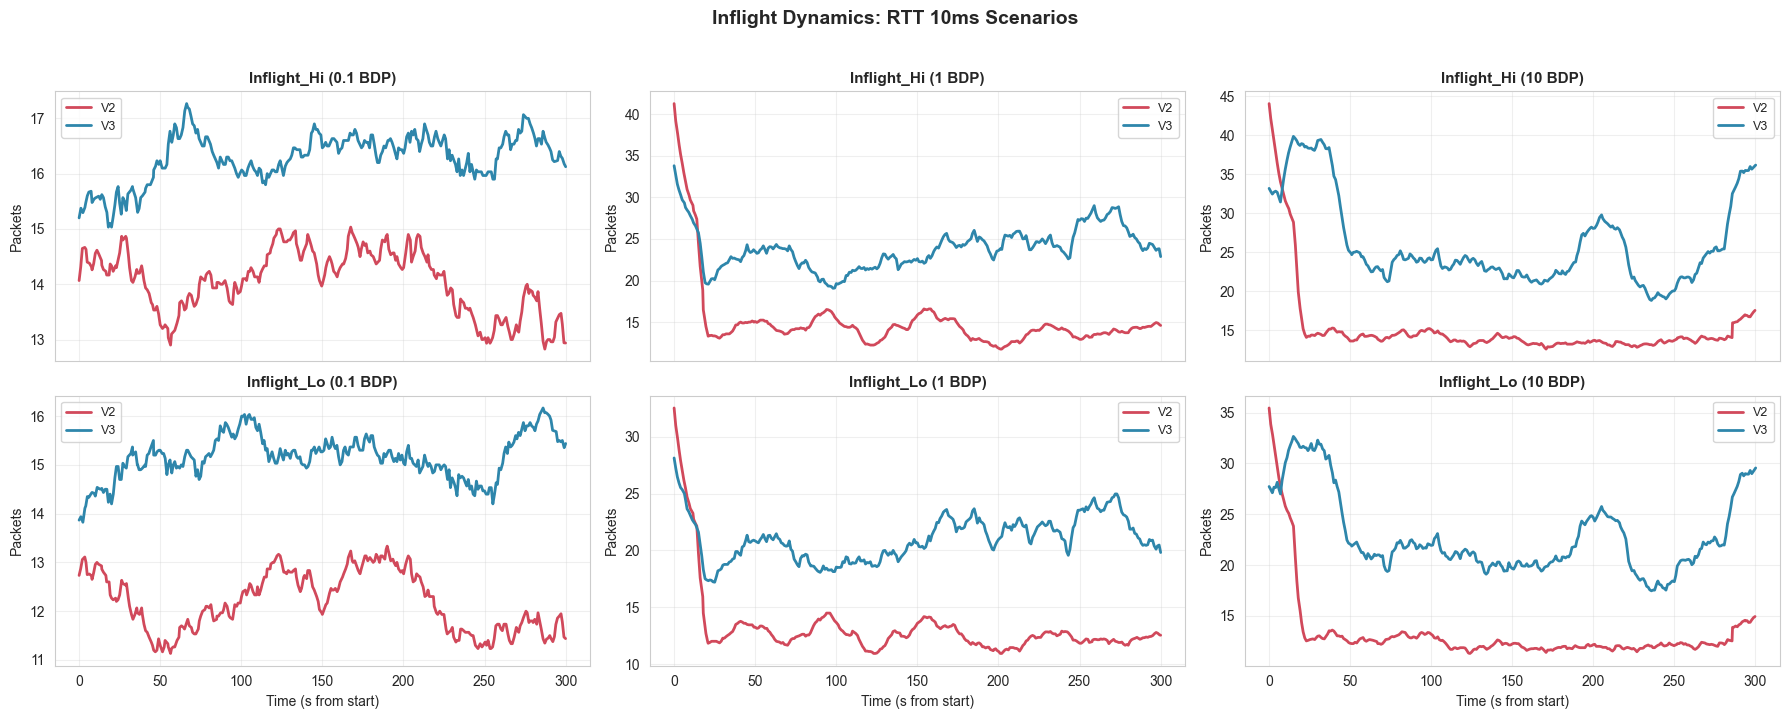

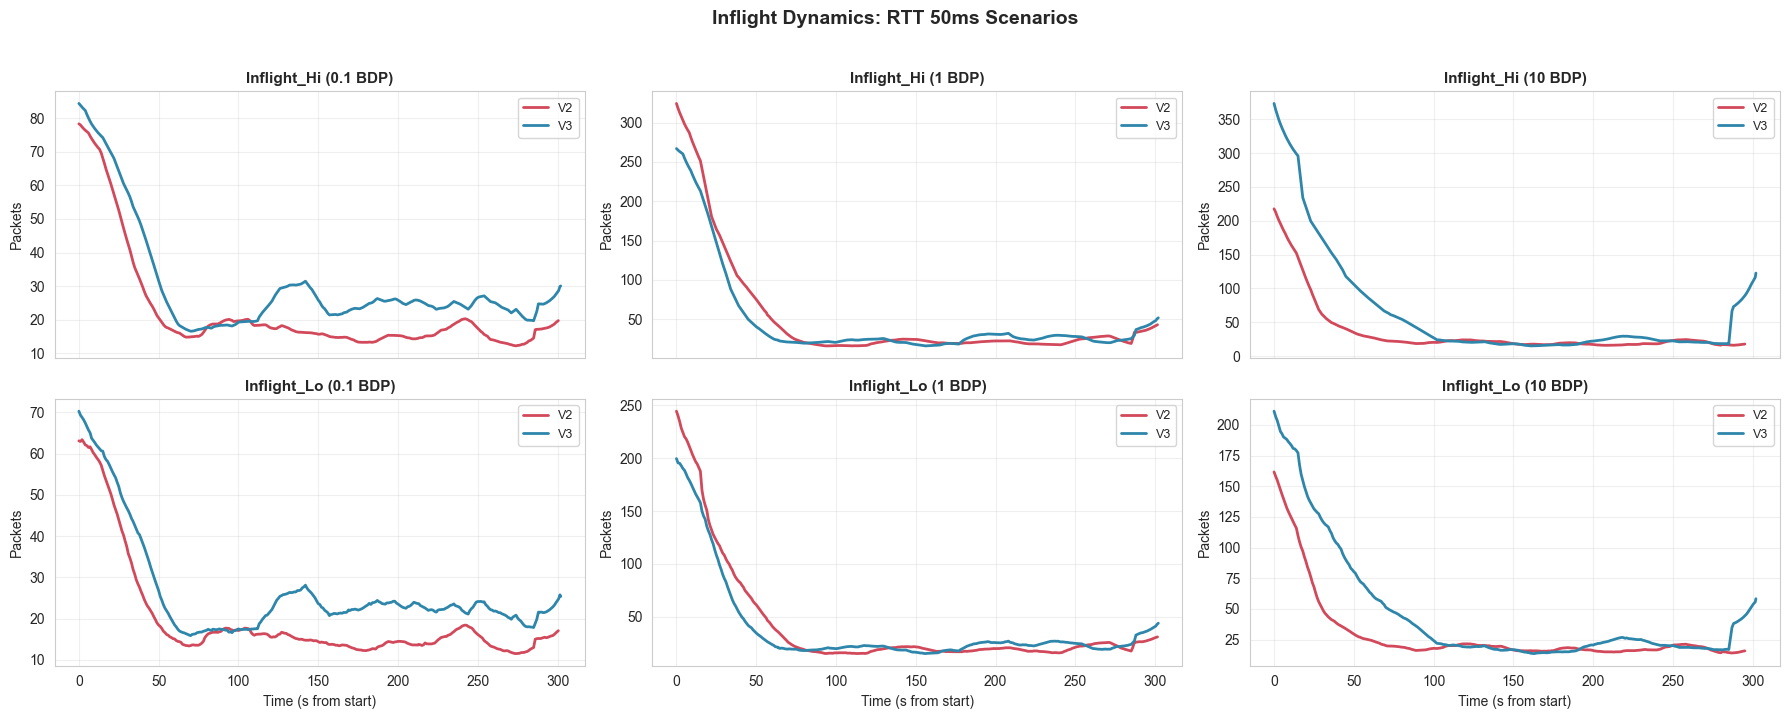

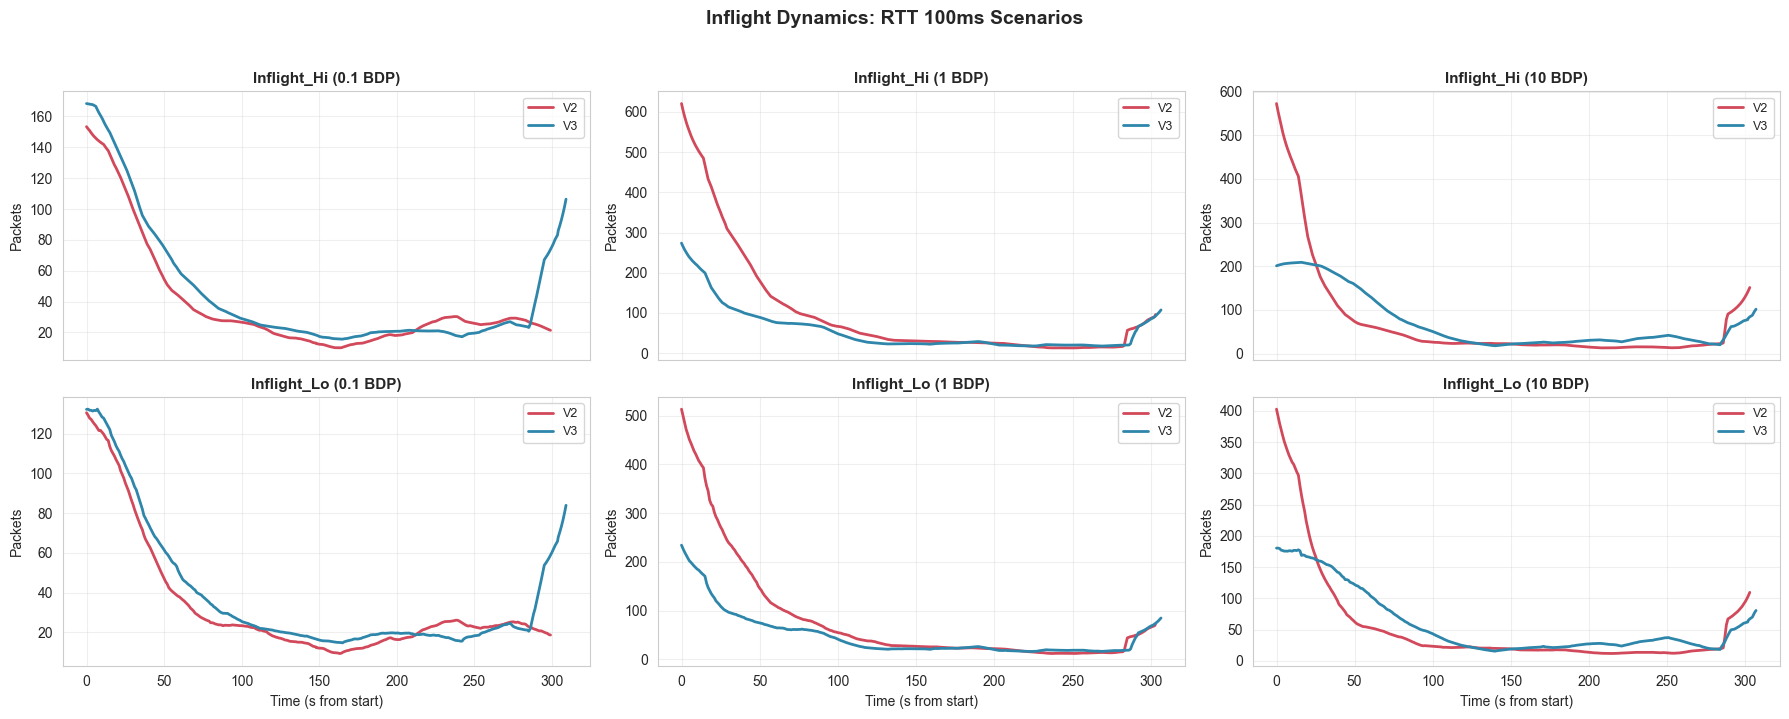

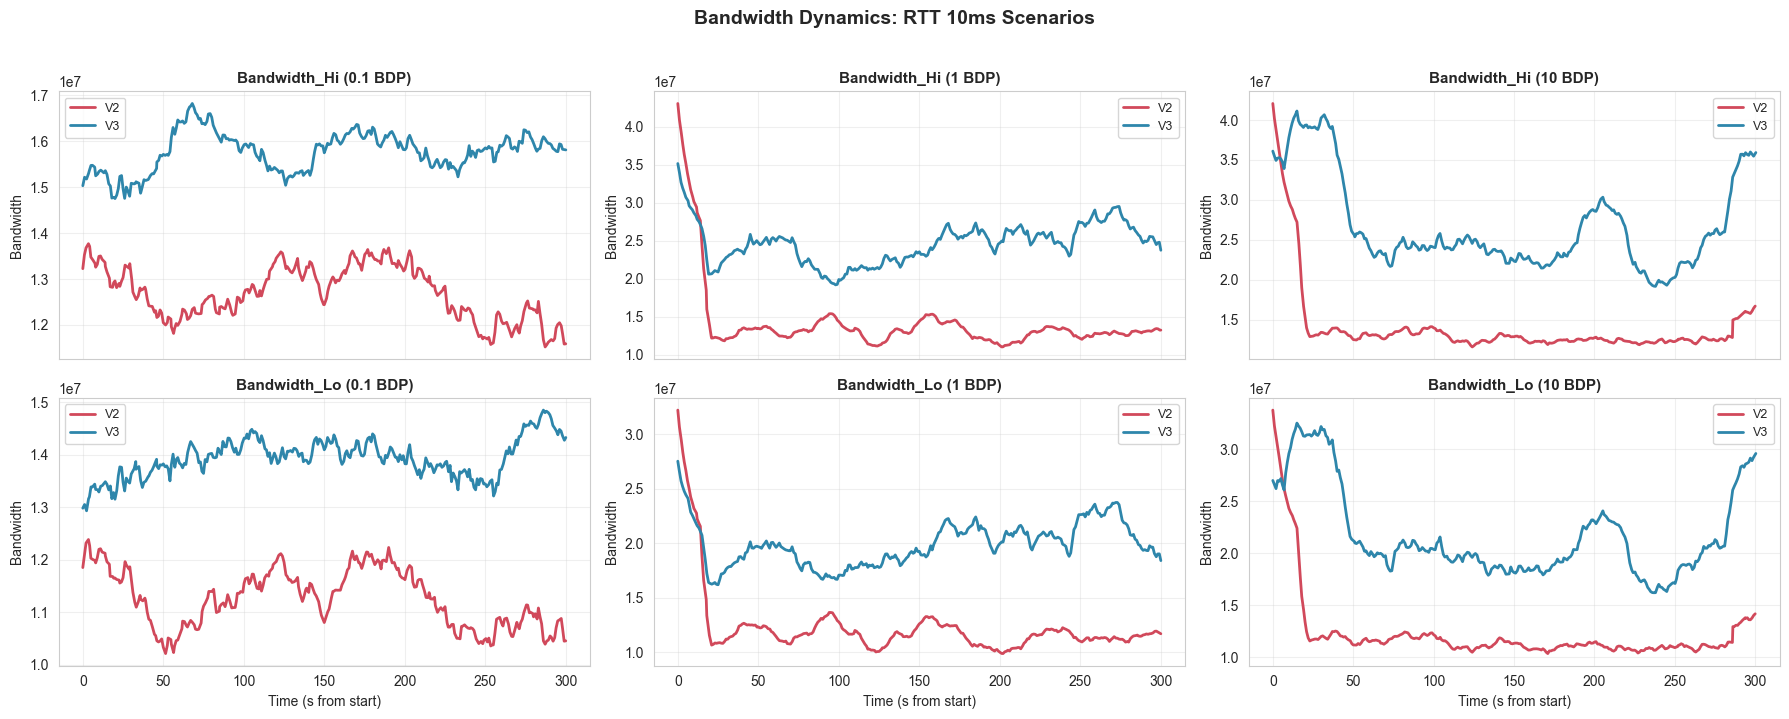

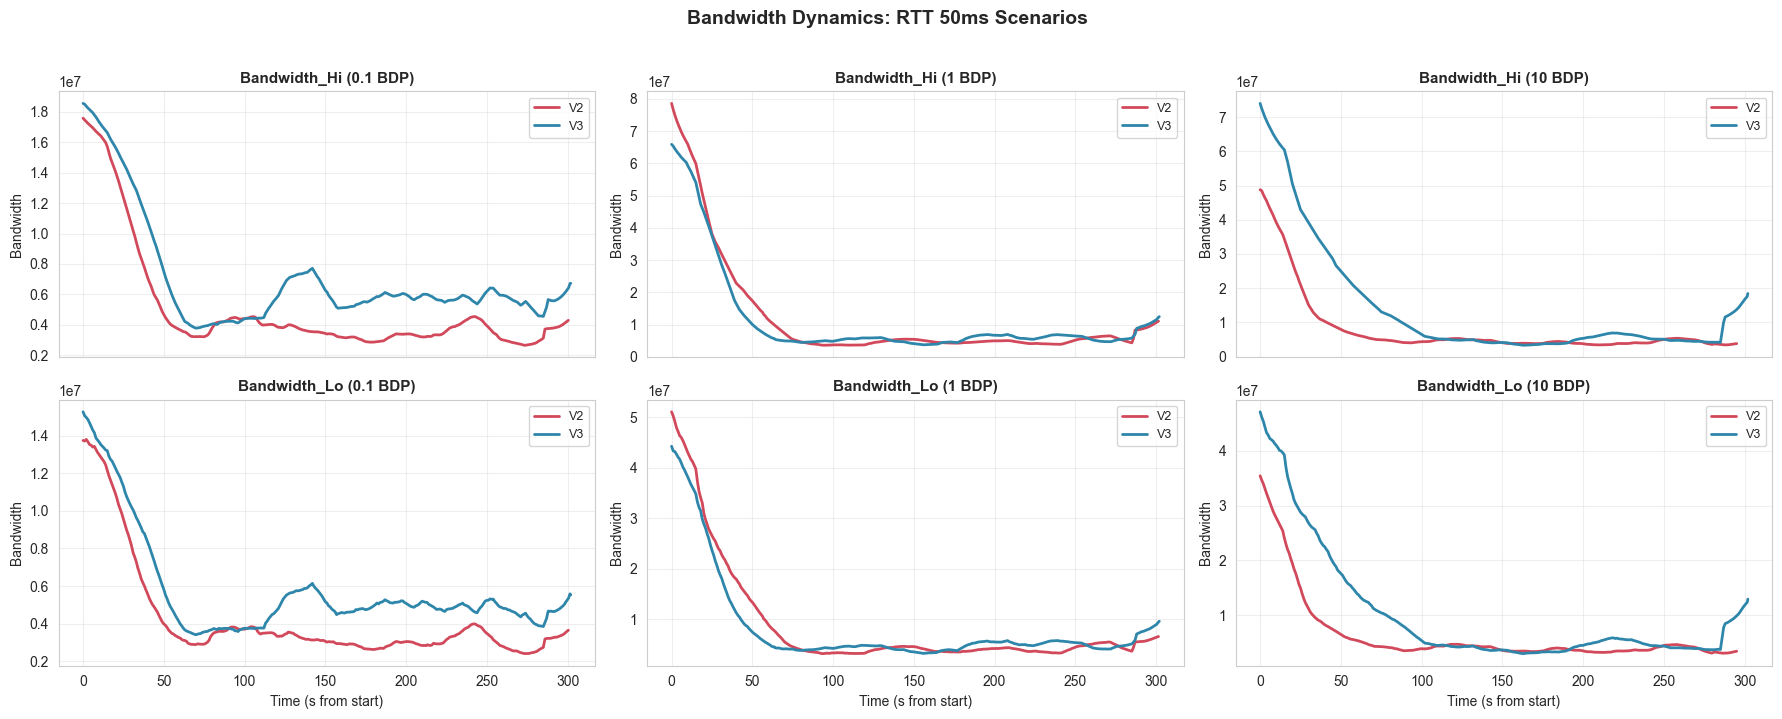

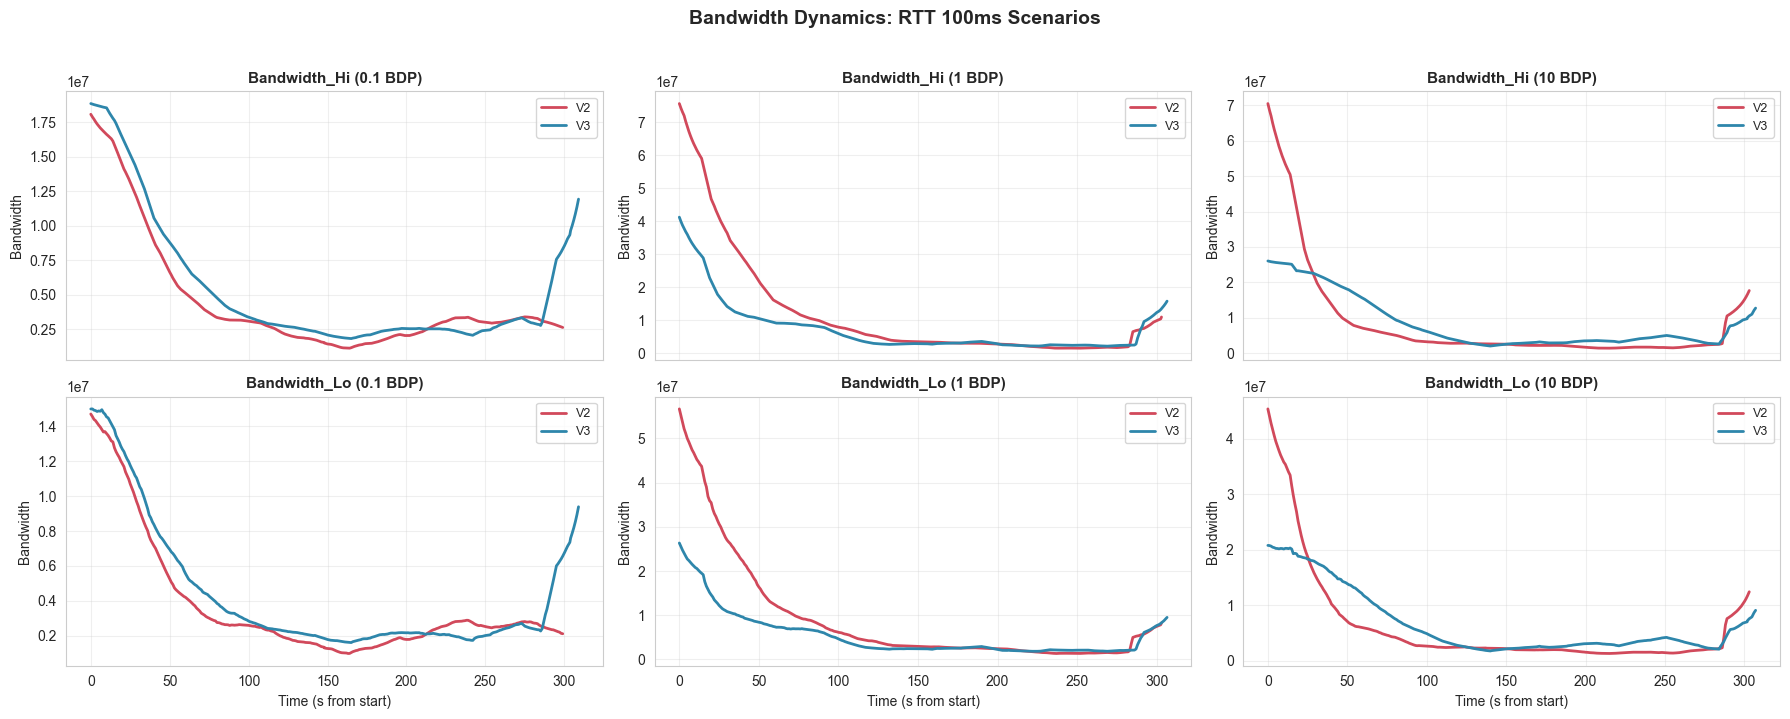

In [41]:
# Inflight dynamics: compare inflight_hi and inflight_lo for v2 vs v3

def plot_inflight_group(group_title, scenario_specs):
    n_cols = len(scenario_specs)
    fig, axes = plt.subplots(2, n_cols, figsize=(6 * n_cols, 7), sharex='col')
    if n_cols == 1:
        axes = np.array(axes).reshape(2, 1)

    for col_idx, (key, label) in enumerate(scenario_specs):
        ax_hi = axes[0, col_idx]
        ax_lo = axes[1, col_idx]

        for version, color in [('v2', C_V2), ('v3', C_V3)]:
            df = data[key][version].sort_values('timestamp').reset_index(drop=True)
            x = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
            window = max(15, min(150, len(df) // 10))

            inflight_hi_smooth = df['inflight_hi'].rolling(window=window, center=True, min_periods=1).mean()
            inflight_lo_smooth = df['inflight_lo'].rolling(window=window, center=True, min_periods=1).mean()

            ax_hi.plot(x, inflight_hi_smooth, label=version.upper(), color=color, linewidth=2)
            ax_lo.plot(x, inflight_lo_smooth, label=version.upper(), color=color, linewidth=2)

        ax_hi.set_title(f'Inflight_Hi ({label})', fontsize=11, fontweight='bold')
        ax_lo.set_title(f'Inflight_Lo ({label})', fontsize=11, fontweight='bold')
        ax_hi.set_ylabel('Packets')
        ax_lo.set_ylabel('Packets')
        ax_lo.set_xlabel('Time (s from start)')
        ax_hi.grid(True, alpha=0.3)
        ax_lo.grid(True, alpha=0.3)
        ax_hi.legend(fontsize=9)
        ax_lo.legend(fontsize=9)

    fig.suptitle(group_title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


plot_inflight_group(
    'Inflight Dynamics: RTT 10ms Scenarios',
    [
        ('rtt10_0.1bdp', '0.1 BDP'),
        ('rtt10_1bdp', '1 BDP'),
        ('rtt10_10bdp', '10 BDP'),
    ],
)

plot_inflight_group(
    'Inflight Dynamics: RTT 50ms Scenarios',
    [
        ('rtt50_0.1bdp', '0.1 BDP'),
        ('rtt50_1bdp', '1 BDP'),
        ('rtt50_10bdp', '10 BDP'),
    ],
)

plot_inflight_group(
    'Inflight Dynamics: RTT 100ms Scenarios',
    [
        ('rtt100_0.1bdp', '0.1 BDP'),
        ('rtt100_1bdp', '1 BDP'),
        ('rtt100_10bdp', '10 BDP'),
    ],
)


# Bandwidth dynamics: compare bw_hi and bw_lo for v2 vs v3

def plot_bandwidth_group(group_title, scenario_specs):
    n_cols = len(scenario_specs)
    fig, axes = plt.subplots(2, n_cols, figsize=(6 * n_cols, 7), sharex='col')
    if n_cols == 1:
        axes = np.array(axes).reshape(2, 1)

    for col_idx, (key, label) in enumerate(scenario_specs):
        ax_hi = axes[0, col_idx]
        ax_lo = axes[1, col_idx]

        for version, color in [('v2', C_V2), ('v3', C_V3)]:
            df = data[key][version].sort_values('timestamp').reset_index(drop=True)
            x = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
            window = max(15, min(150, len(df) // 10))

            bw_hi_smooth = df['bw_hi'].rolling(window=window, center=True, min_periods=1).mean()
            bw_lo_smooth = df['bw_lo'].rolling(window=window, center=True, min_periods=1).mean()

            ax_hi.plot(x, bw_hi_smooth, label=version.upper(), color=color, linewidth=2)
            ax_lo.plot(x, bw_lo_smooth, label=version.upper(), color=color, linewidth=2)

        ax_hi.set_title(f'Bandwidth_Hi ({label})', fontsize=11, fontweight='bold')
        ax_lo.set_title(f'Bandwidth_Lo ({label})', fontsize=11, fontweight='bold')
        ax_hi.set_ylabel('Bandwidth')
        ax_lo.set_ylabel('Bandwidth')
        ax_lo.set_xlabel('Time (s from start)')
        ax_hi.grid(True, alpha=0.3)
        ax_lo.grid(True, alpha=0.3)
        ax_hi.legend(fontsize=9)
        ax_lo.legend(fontsize=9)

    fig.suptitle(group_title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


plot_bandwidth_group(
    'Bandwidth Dynamics: RTT 10ms Scenarios',
    [
        ('rtt10_0.1bdp', '0.1 BDP'),
        ('rtt10_1bdp', '1 BDP'),
        ('rtt10_10bdp', '10 BDP'),
    ],
)

plot_bandwidth_group(
    'Bandwidth Dynamics: RTT 50ms Scenarios',
    [
        ('rtt50_0.1bdp', '0.1 BDP'),
        ('rtt50_1bdp', '1 BDP'),
        ('rtt50_10bdp', '10 BDP'),
    ],
)

plot_bandwidth_group(
    'Bandwidth Dynamics: RTT 100ms Scenarios',
    [
        ('rtt100_0.1bdp', '0.1 BDP'),
        ('rtt100_1bdp', '1 BDP'),
        ('rtt100_10bdp', '10 BDP'),
    ],
)


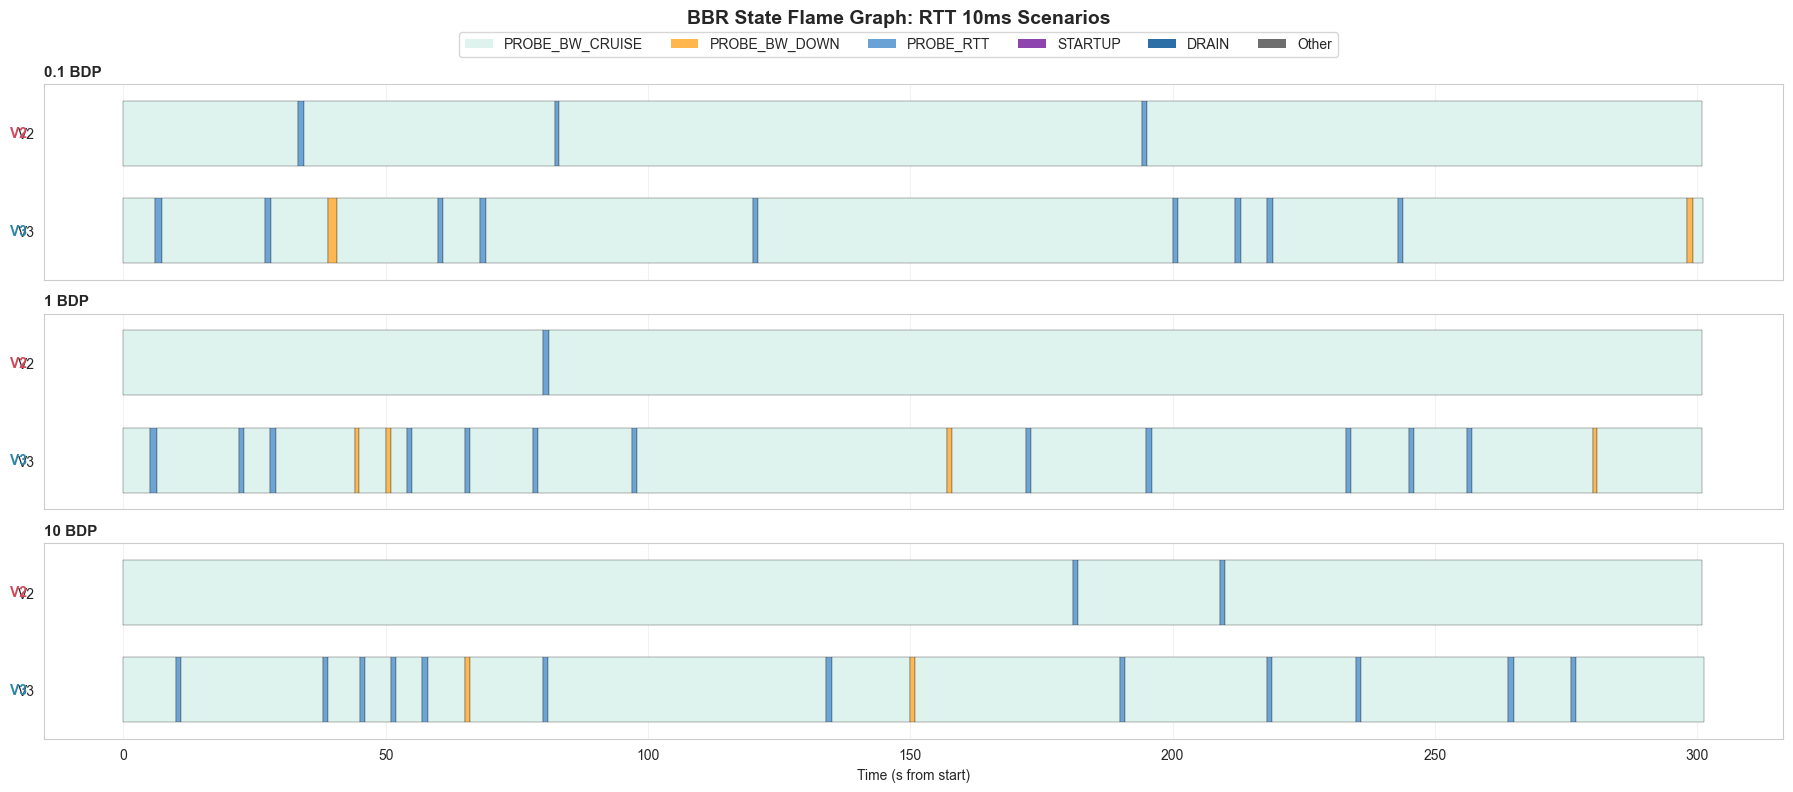

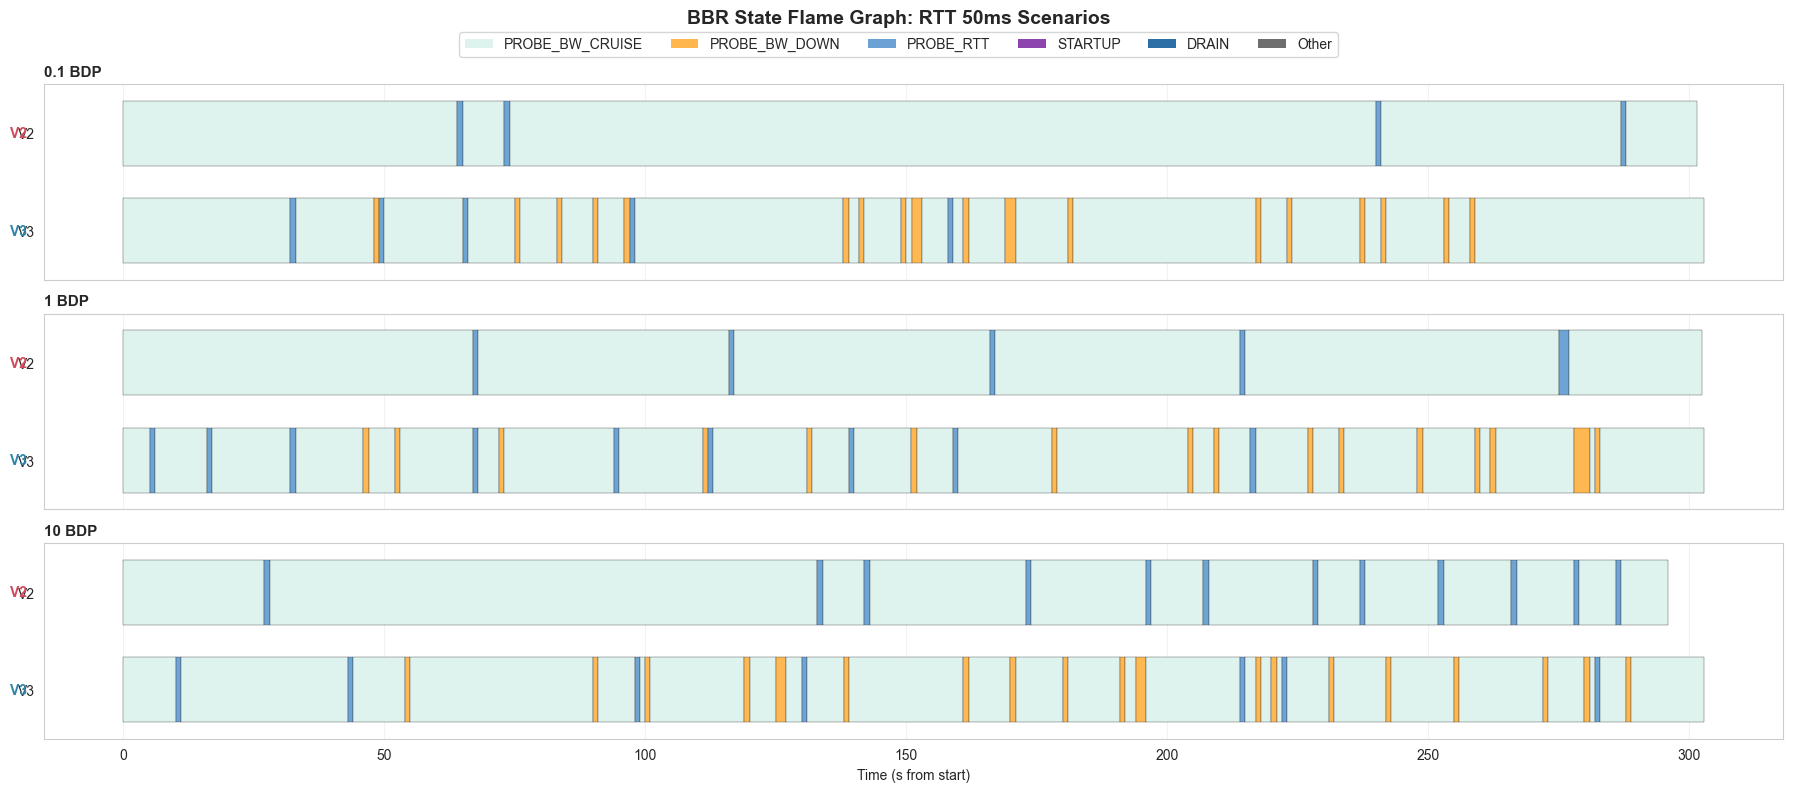

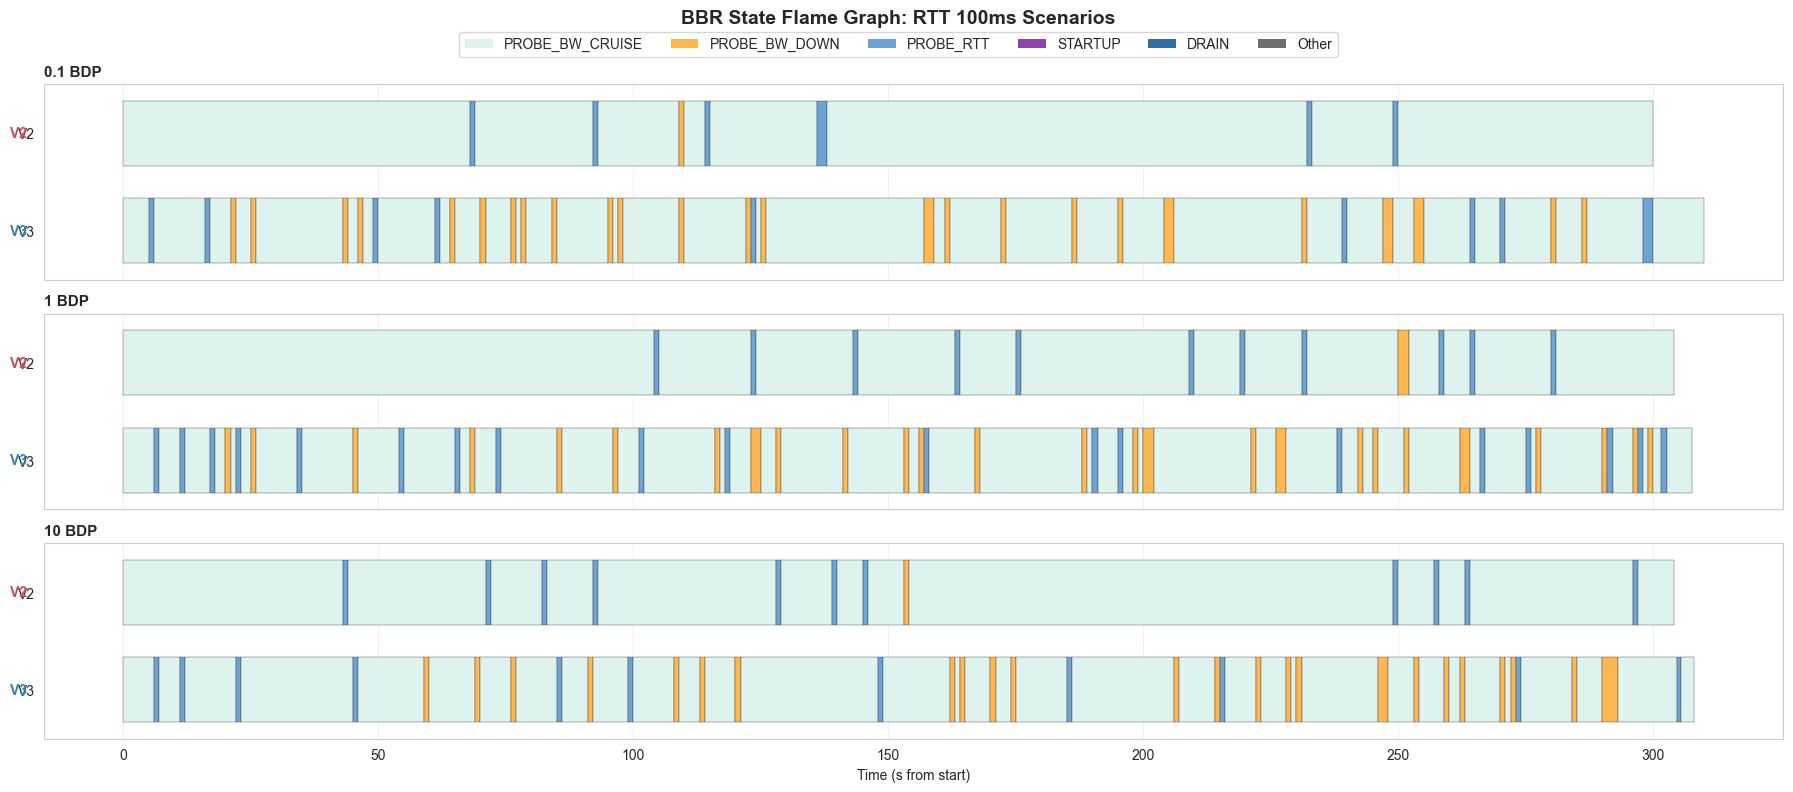

In [42]:
# Flame graph: visualize BBR states over time for v2 vs v3
from matplotlib.patches import Patch

# prettier, muted palette for phases
PHASE_COLORS = {
    # soft, harmonious palette (muted / print-friendly)
    'PROBE_BW_CRUISE': '#dff3ee',  # light mint
    'PROBE_BW_DOWN': '#ffb74d',    # warm soft orange
    'PROBE_RTT': '#6aa2d6',        # muted blue
    'STARTUP': '#8e44ad',          # vibrant purple
    'DRAIN': '#2b6fa6',            # deep steel blue
}
DEFAULT_PHASE_COLOR = '#6e6e6e'


def _phase_segments(df):
    df = df.sort_values('timestamp').reset_index(drop=True)
    if df.empty:
        return []

    x = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
    diffs = np.diff(x.to_numpy())
    if len(diffs) and np.any(diffs > 0):
        default_step = float(np.median(diffs[diffs > 0]))
    else:
        default_step = 1.0

    durations = np.append(np.where(diffs > 0, diffs, default_step), default_step)
    segments = []
    run_phase = df['phase'].iloc[0]
    run_start = float(x.iloc[0])
    run_width = float(durations[0])

    for idx in range(1, len(df)):
        phase = df['phase'].iloc[idx]
        if phase == run_phase:
            run_width += float(durations[idx])
        else:
            segments.append((run_start, run_width, run_phase))
            run_phase = phase
            run_start = float(x.iloc[idx])
            run_width = float(durations[idx])

    segments.append((run_start, run_width, run_phase))
    return segments


def plot_phase_flame_group(group_title, scenario_specs):
    fig, axes = plt.subplots(
        len(scenario_specs),
        1,
        figsize=(18, max(3.0, 2.6 * len(scenario_specs))),
        sharex=True,
    )
    if len(scenario_specs) == 1:
        axes = [axes]

    legend_handles = [Patch(facecolor=color, edgecolor='none', label=phase) for phase, color in PHASE_COLORS.items()]
    legend_handles.append(Patch(facecolor=DEFAULT_PHASE_COLOR, edgecolor='none', label='Other'))

    for ax, (key, label) in zip(axes, scenario_specs):
        lane_specs = [('v2', C_V2, 12), ('v3', C_V3, 0)]
        for version, line_color, y_base in lane_specs:
            df = data[key][version].sort_values('timestamp').reset_index(drop=True)
            for start, width, phase in _phase_segments(df):
                ax.broken_barh(
                    [(start, width)],
                    (y_base, 8),
                    facecolors=PHASE_COLORS.get(phase, DEFAULT_PHASE_COLOR),
                    edgecolors='#222222',
                    linewidth=0.25,
                    alpha=0.98,
                )

            ax.text(-0.01, y_base + 4, version.upper(), va='center', ha='right', fontsize=10, fontweight='bold', color=line_color, transform=ax.get_yaxis_transform())

        ax.set_ylim(-2, 22)
        ax.set_yticks([4, 16])
        ax.set_yticklabels(['V3', 'V2'])
        ax.set_title(label, fontsize=11, fontweight='bold', loc='left')
        ax.grid(True, axis='x', alpha=0.25)
        ax.grid(False, axis='y')

    axes[-1].set_xlabel('Time (s from start)')
    fig.suptitle(group_title, fontsize=14, fontweight='bold', y=1.01)
    fig.legend(handles=legend_handles, loc='upper center', ncol=min(6, len(legend_handles)), frameon=True, bbox_to_anchor=(0.5, 0.99))
    plt.tight_layout()
    plt.show()


plot_phase_flame_group(
    'BBR State Flame Graph: RTT 10ms Scenarios',
    [
        ('rtt10_0.1bdp', '0.1 BDP'),
        ('rtt10_1bdp', '1 BDP'),
        ('rtt10_10bdp', '10 BDP'),
    ],
)

plot_phase_flame_group(
    'BBR State Flame Graph: RTT 50ms Scenarios',
    [
        ('rtt50_0.1bdp', '0.1 BDP'),
        ('rtt50_1bdp', '1 BDP'),
        ('rtt50_10bdp', '10 BDP'),
    ],
)

plot_phase_flame_group(
    'BBR State Flame Graph: RTT 100ms Scenarios',
    [
        ('rtt100_0.1bdp', '0.1 BDP'),
        ('rtt100_1bdp', '1 BDP'),
        ('rtt100_10bdp', '10 BDP'),
    ],
)
